In [5]:
#2. Import libraries 

import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from config import PROCESSED_DATA, TABLES, FIGURES
from utils import find_col

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully")

Libraries imported successfully


In [8]:
# 3. Load your CSV 

df = pd.read_csv(r"C:\Users\A D M I N\Documents\Healthcare Providers-capstone1 u.csv")
df
print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully
Rows: 100000
Columns: 27


In [ ]:
#4. View the data

In [8]:
df.head()

,index,National Provider Identifier,Last Name/Organization Name of the Provider,First Name of the Provider,Middle Initial of the Provider,Credentials of the Provider,Gender of the Provider,Entity Type of the Provider,Street Address 1 of the Provider,Street Address 2 of the Provider,City of the Provider,Zip Code of the Provider,State Code of the Provider,Country Code of the Provider,Provider Type,Medicare Participation Indicator,Place of Service,HCPCS Code,HCPCS Description,HCPCS Drug Indicator,Number of Services,Number of Medicare Beneficiaries,Number of Distinct Medicare Beneficiary/Per Day Services,Average Medicare Allowed Amount,Average Submitted Charge Amount,Average Medicare Payment Amount,Average Medicare Standardized Amount
0,8774979,1891106191,UPADHYAYULA,SATYASREE,NaN,M.D.,F,I,1402 S GRAND BLVD,FDT 14TH FLOOR,SAINT LOUIS,631041004,MO,US,Internal Medicine,Y,F,99223,"Initial hospital inpatient care, typically 70 ...",N,27,24,27,200.5877778,305.2111111,157.2622222,160.9088889
1,3354385,1346202256,JONES,WENDY,P,M.D.,F,I,2950 VILLAGE DR,NaN,FAYETTEVILLE,283043815,NC,US,Obstetrics & Gynecology,Y,O,G0202,"Screening mammography, bilateral (2-view study...",N,175,175,175,123.73,548.8,118.83,135.3152571
2,3001884,1306820956,DUROCHER,RICHARD,W,DPM,M,I,20 WASHINGTON AVE,STE 212,NORTH HAVEN,64732343,CT,US,Podiatry,Y,O,99348,"Established patient home visit, typically 25 m...",N,32,13,32,90.65,155,64.4396875,60.5959375
3,7594822,1770523540,FULLARD,JASPER,NaN,MD,M,I,5746 N BROADWAY ST,NaN,KANSAS CITY,641183998,MO,US,Internal Medicine,Y,O,81002,"Urinalysis, manual test",N,20,18,20,3.5,5,3.43,3.43
4,746159,1073627758,PERROTTI,ANTHONY,E,DO,M,I,875 MILITARY TRL,SUITE 200,JUPITER,334585700,FL,US,Internal Medicine,Y,O,96372,Injection beneath the skin or into muscle for ...,N,33,24,31,26.52,40,19.53939394,19.05757576


In [9]:
df.tail()

,index,National Provider Identifier,Last Name/Organization Name of the Provider,First Name of the Provider,Middle Initial of the Provider,Credentials of the Provider,Gender of the Provider,Entity Type of the Provider,Street Address 1 of the Provider,Street Address 2 of the Provider,City of the Provider,Zip Code of the Provider,State Code of the Provider,Country Code of the Provider,Provider Type,Medicare Participation Indicator,Place of Service,HCPCS Code,HCPCS Description,HCPCS Drug Indicator,Number of Services,Number of Medicare Beneficiaries,Number of Distinct Medicare Beneficiary/Per Day Services,Average Medicare Allowed Amount,Average Submitted Charge Amount,Average Medicare Payment Amount,Average Medicare Standardized Amount
99995,3837311,1386938868,PAPES,JOAN,NaN,PT,F,I,324 E BALTIMORE ST,NaN,WILMINGTON,604811236,IL,US,Physical Therapist in Private Practice,Y,O,97162,"Evaluation of physical therapy, typically 30 m...",N,20,20,20,85.3725,214,60.7255,62.2485
99996,2079360,1215091327,HAYNER,MARGARET,S,ARNP,F,I,645 NW 4TH ST,NaN,REDMOND,977561502,OR,US,Nurse Practitioner,Y,O,99213,Established patient office or other outpatient...,N,136,107,136,61.27,144.0514706,30.00617647,37.04022059
99997,8927965,1902868185,VALENCIA,DANA,NaN,M.D.,M,I,3009 N BALLAS RD,SUITE 202B,SAINT LOUIS,631312322,MO,US,Cardiology,Y,F,93320,"Doppler ultrasound study of heart blood flow, ...",N,11,11,11,17.98,109.5454546,14.09,14.62
99998,8854571,1891941183,GONZALEZ-LAMOS,RAFAELA,NaN,NaN,F,I,2365 BOSTON POST RD,SUITE 201,LARCHMONT,105383500,NY,US,Internal Medicine,Y,O,G0008,Administration of influenza virus vaccine,N,12,12,12,30.54,65,29.93,25.32
99999,3547535,1356772156,RAMEZANI,ELIIAN,NaN,NaN,F,I,444 MIDDLE NECK RD APT 1H,NaN,GREAT NECK,11023,NY,US,Physical Therapist in Private Practice,Y,O,97112,Therapeutic procedure to re-educate brain-to-n...,N,589,76,587,38.60105263,46.86757216,29.73687606,25.91213922


In [10]:
df.sample(5)

,index,National Provider Identifier,Last Name/Organization Name of the Provider,First Name of the Provider,Middle Initial of the Provider,Credentials of the Provider,Gender of the Provider,Entity Type of the Provider,Street Address 1 of the Provider,Street Address 2 of the Provider,City of the Provider,Zip Code of the Provider,State Code of the Provider,Country Code of the Provider,Provider Type,Medicare Participation Indicator,Place of Service,HCPCS Code,HCPCS Description,HCPCS Drug Indicator,Number of Services,Number of Medicare Beneficiaries,Number of Distinct Medicare Beneficiary/Per Day Services,Average Medicare Allowed Amount,Average Submitted Charge Amount,Average Medicare Payment Amount,Average Medicare Standardized Amount
72786,3946372,1407027998,NACE,SARA,R,M.D.,F,I,166 4TH ST E,NaN,SAINT PAUL,551011421,MN,US,Diagnostic Radiology,Y,F,72158,MRI scan of lower spinal canal before and afte...,N,21,21,21,115.13,352.3333333,90.13095238,89.19
69300,5581183,1568558245,SCHRECK,DOUGLAS,E,MD,M,I,201 S BUENA VISTA ST,SUITE 100,BURBANK,915054569,CA,US,Cardiology,Y,F,99215,Established patient office or other outpatient...,N,18,18,18,120.52,241,94.49,88.36
68517,4024735,1407913478,AINSLIE,MARCY,M,APRN,F,I,510 NORTH MAIN STREET,LEOMINSTER URGENT CARE,LEOMINSTER,1453,MA,US,Nurse Practitioner,Y,O,99213,Established patient office or other outpatient...,N,35,35,35,44.07,248,32.71857143,32.61171429
80450,3013938,1306841564,ROBINSON,EDWIN,G,MD,M,I,1800 GLENSIDE DR,SUITE 105,RICHMOND,232263769,VA,US,Family Practice,Y,O,85048,Automated white blood cell count,N,26,25,26,3.48,10,3.41,3.41
50917,1535086,1154501393,THOMAS,MICHAEL,E,M.D.,M,I,70 DOCTORS PARK,NaN,CAPE GIRARDEAU,637034928,MO,US,Diagnostic Radiology,Y,F,73564,"X-ray of knee, 4 or more views",N,34,32,32,11.25705882,46,8.043235294,8.223823529


In [22]:
# 5. Dataset information 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                                                    Non-Null Count   Dtype
---  ------                                                    --------------   -----
 0   index                                                     100000 non-null  int64
 1   National Provider Identifier                              100000 non-null  int64
 2   Last Name/Organization Name of the Provider               100000 non-null  str  
 3   First Name of the Provider                                95745 non-null   str  
 4   Middle Initial of the Provider                            70669 non-null   str  
 5   Credentials of the Provider                               92791 non-null   str  
 6   Gender of the Provider                                    95746 non-null   str  
 7   Entity Type of the Provider                               100000 non-null  str  
 8   Street Address 1 of the Provider    

In [12]:
df.shape

(100000, 27)

In [13]:
df.columns.tolist()

['index',
 'National Provider Identifier',
 'Last Name/Organization Name of the Provider',
 'First Name of the Provider',
 'Middle Initial of the Provider',
 'Credentials of the Provider',
 'Gender of the Provider',
 'Entity Type of the Provider',
 'Street Address 1 of the Provider',
 'Street Address 2 of the Provider',
 'City of the Provider',
 'Zip Code of the Provider',
 'State Code of the Provider',
 'Country Code of the Provider',
 'Provider Type',
 'Medicare Participation Indicator',
 'Place of Service',
 'HCPCS Code',
 'HCPCS Description',
 'HCPCS Drug Indicator',
 'Number of Services',
 'Number of Medicare Beneficiaries',
 'Number of Distinct Medicare Beneficiary/Per Day Services',
 'Average Medicare Allowed Amount',
 'Average Submitted Charge Amount',
 'Average Medicare Payment Amount',
 'Average Medicare Standardized Amount']

In [ ]:
# 6. Missing-value analysis
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Missing %": (`missing.values / len(df)` * 100).round(2)
})

missing_df.sort_values("Missing Values", ascending=False)

,Column,Missing Values,Missing %
9,Street Address 2 of the Provider,59363,59.36
4,Middle Initial of the Provider,29331,29.33
5,Credentials of the Provider,7209,7.21
3,First Name of the Provider,4255,4.26
6,Gender of the Provider,4254,4.25
0,index,0,0.00
1,National Provider Identifier,0,0.00
2,Last Name/Organization Name of the Provider,0,0.00
7,Entity Type of the Provider,0,0.00
8,Street Address 1 of the Provider,0,0.00


In [ ]:
#7. Duplicate analysis
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (100000, 27)


In [ ]:
# 7. Duplicate analysis 
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,100000.0,NaN,NaN,NaN,4907645.74603,2839632.695465,209.0,2458790.75,4901266.0,7349450.5,9847440.0
National Provider Identifier,100000.0,NaN,NaN,NaN,1498226858.04662,287412506.095332,1003001298.0,1245669407.25,1497846612.0,1740373949.25,1992999874.0
Last Name/Organization Name of the Provider,100000,42820,PATEL,557,NaN,NaN,NaN,NaN,NaN,NaN,NaN
First Name of the Provider,95745,13022,MICHAEL,2350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Middle Initial of the Provider,70669,29,A,8152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credentials of the Provider,92791,1854,MD,32874,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender of the Provider,95746,2,M,66641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Entity Type of the Provider,100000,2,I,95746,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Street Address 1 of the Provider,100000,51928,200 1ST ST SW,244,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Street Address 2 of the Provider,40637,10024,SUITE 200,1624,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,100000.0,4.907646e+06,2.839633e+06,2.090000e+02,2.458791e+06,4.901266e+06,7.349450e+06,9.847440e+06
National Provider Identifier,100000.0,1.498227e+09,2.874125e+08,1.003001e+09,1.245669e+09,1.497847e+09,1.740374e+09,1.993000e+09
Zip Code of the Provider,100000.0,4.163820e+08,3.082566e+08,6.010000e+02,1.426300e+08,3.633025e+08,6.819881e+08,9.990166e+08


In [25]:
# 9. Provider Type Analysis 
provider_type = df["Provider Type"].value_counts().head(10)

provider_type

Provider Type
Diagnostic Radiology                      12537
Internal Medicine                         11366
Family Practice                            9760
Nurse Practitioner                         5713
Cardiology                                 4602
Physician Assistant                        3818
Orthopedic Surgery                         3098
Physical Therapist in Private Practice     2780
Ophthalmology                              2495
Emergency Medicine                         2377
Name: count, dtype: int64

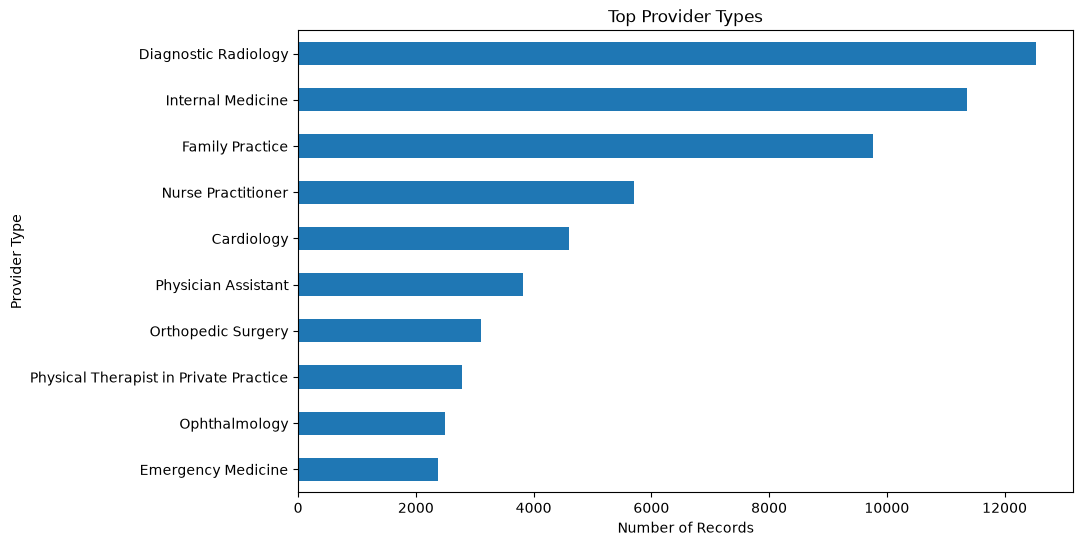

In [20]:
plt.figure(figsize=(10, 6))

provider_type.sort_values().plot(kind="barh")

plt.title("Top Provider Types")
plt.xlabel("Number of Records")
plt.ylabel("Provider Type")
plt.show()

In [31]:
# # 10. State Analysis
print(df.columns.tolist())

['index', 'National Provider Identifier', 'Last Name/Organization Name of the Provider', 'First Name of the Provider', 'Middle Initial of the Provider', 'Credentials of the Provider', 'Gender of the Provider', 'Entity Type of the Provider', 'Street Address 1 of the Provider', 'Street Address 2 of the Provider', 'City of the Provider', 'Zip Code of the Provider', 'State Code of the Provider', 'Country Code of the Provider', 'Provider Type', 'Medicare Participation Indicator', 'Place of Service', 'HCPCS Code', 'HCPCS Description', 'HCPCS Drug Indicator', 'Number of Services', 'Number of Medicare Beneficiaries', 'Number of Distinct Medicare Beneficiary/Per Day Services', 'Average Medicare Allowed Amount', 'Average Submitted Charge Amount', 'Average Medicare Payment Amount', 'Average Medicare Standardized Amount']


In [32]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['index', 'National Provider Identifier', 'Last Name/Organization Name of the Provider', 'First Name of the Provider', 'Middle Initial of the Provider', 'Credentials of the Provider', 'Gender of the Provider', 'Entity Type of the Provider', 'Street Address 1 of the Provider', 'Street Address 2 of the Provider', 'City of the Provider', 'Zip Code of the Provider', 'State Code of the Provider', 'Country Code of the Provider', 'Provider Type', 'Medicare Participation Indicator', 'Place of Service', 'HCPCS Code', 'HCPCS Description', 'HCPCS Drug Indicator', 'Number of Services', 'Number of Medicare Beneficiaries', 'Number of Distinct Medicare Beneficiary/Per Day Services', 'Average Medicare Allowed Amount', 'Average Submitted Charge Amount', 'Average Medicare Payment Amount', 'Average Medicare Standardized Amount']


In [34]:
for col in df.columns:
    print(repr(col))

'index'
'National Provider Identifier'
'Last Name/Organization Name of the Provider'
'First Name of the Provider'
'Middle Initial of the Provider'
'Credentials of the Provider'
'Gender of the Provider'
'Entity Type of the Provider'
'Street Address 1 of the Provider'
'Street Address 2 of the Provider'
'City of the Provider'
'Zip Code of the Provider'
'State Code of the Provider'
'Country Code of the Provider'
'Provider Type'
'Medicare Participation Indicator'
'Place of Service'
'HCPCS Code'
'HCPCS Description'
'HCPCS Drug Indicator'
'Number of Services'
'Number of Medicare Beneficiaries'
'Number of Distinct Medicare Beneficiary/Per Day Services'
'Average Medicare Allowed Amount'
'Average Submitted Charge Amount'
'Average Medicare Payment Amount'
'Average Medicare Standardized Amount'


In [35]:
[col for col in df.columns if "state" in col.lower()]

['State Code of the Provider']

Provider Type
Diagnostic Radiology                      12537
Internal Medicine                         11366
Family Practice                            9760
Nurse Practitioner                         5713
Cardiology                                 4602
Physician Assistant                        3818
Orthopedic Surgery                         3098
Physical Therapist in Private Practice     2780
Ophthalmology                              2495
Emergency Medicine                         2377
Name: count, dtype: int64


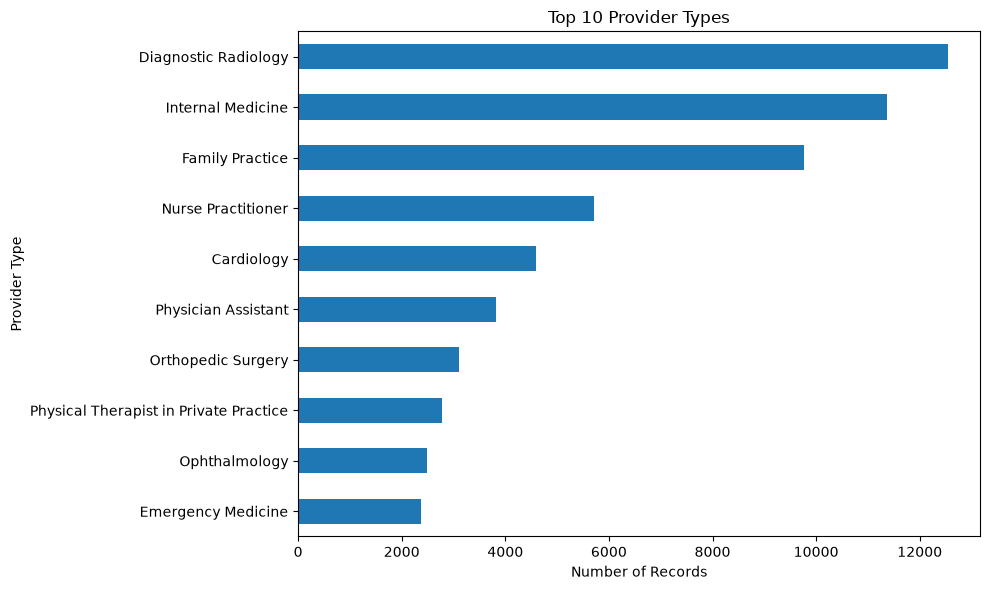

In [42]:
provider_type_counts = df["Provider Type"].value_counts().head(10)

print(provider_type_counts)


plt.figure(figsize=(10, 6))

provider_type_counts.sort_values().plot(kind="barh")

plt.title("Top 10 Provider Types")
plt.xlabel("Number of Records")
plt.ylabel("Provider Type")

plt.tight_layout()
plt.show()

In [28]:
pos_counts = df["Place of Service"].value_counts()

pos_counts

Place of Service
O    61616
F    38384
Name: count, dtype: int64

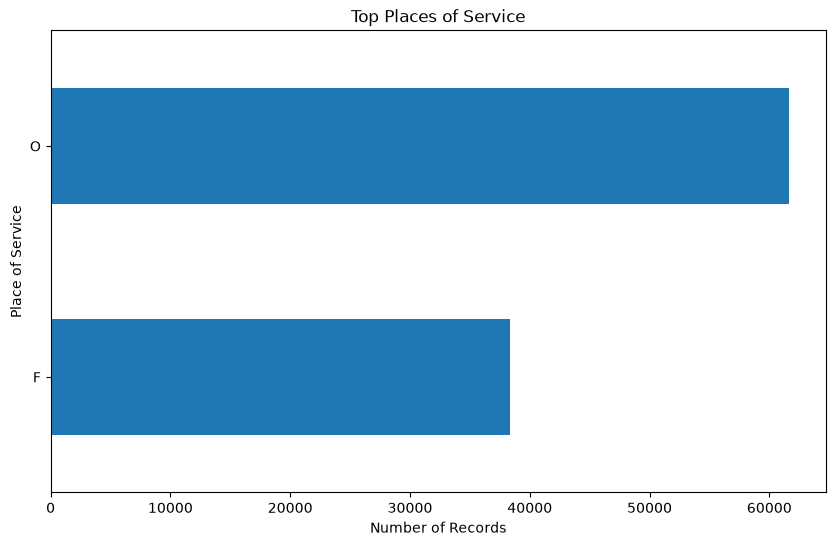

In [43]:
plt.figure(figsize=(10, 6))

pos_counts.head(10).sort_values().plot(kind="barh")

plt.title("Top Places of Service")
plt.xlabel("Number of Records")
plt.ylabel("Place of Service")

plt.show()

In [44]:
top_services = df["HCPCS Description"].value_counts().head(10)

top_services

HCPCS Description
Established patient office or other outpatient visit, typically 15 minutes    4578
Established patient office or other outpatient, visit typically 25 minutes    4401
Subsequent hospital inpatient care, typically 25 minutes per day              1851
New patient office or other outpatient visit, typically 30 minutes            1846
New patient office or other outpatient visit, typically 45 minutes            1743
Administration of influenza virus vaccine                                     1444
Established patient office or other outpatient visit, typically 10 minutes    1344
Initial hospital inpatient care, typically 70 minutes per day                 1297
Subsequent hospital inpatient care, typically 35 minutes per day              1231
Established patient office or other outpatient, visit typically 40 minutes    1226
Name: count, dtype: int64

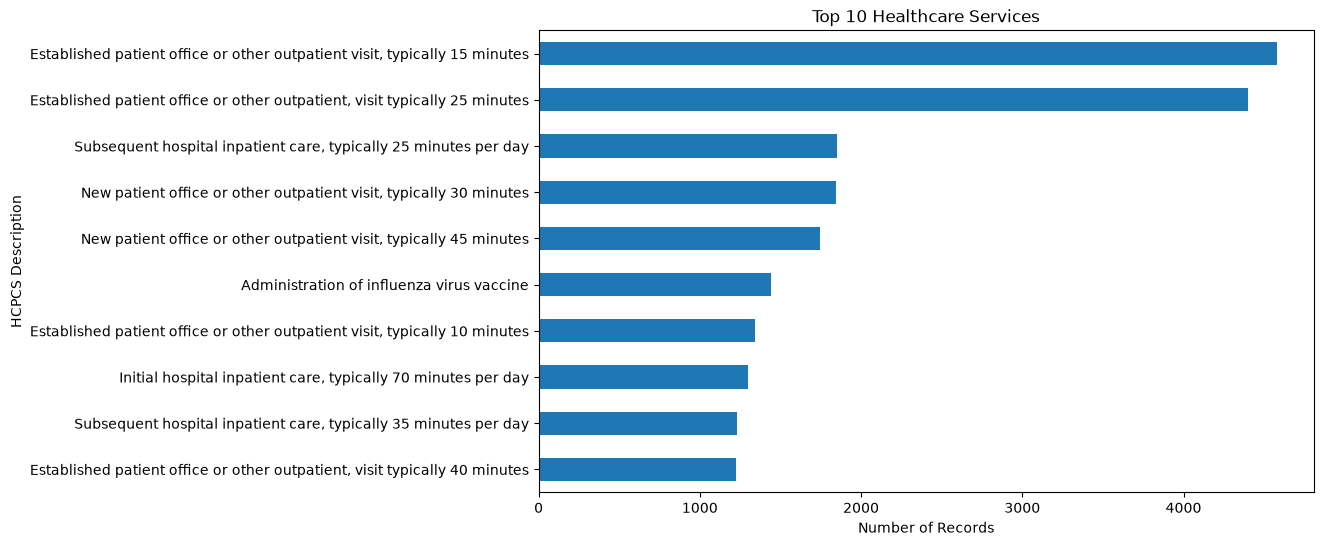

In [45]:
plt.figure(figsize=(10, 6))

top_services.sort_values().plot(kind="barh")

plt.title("Top 10 Healthcare Services")
plt.xlabel("Number of Records")
plt.ylabel("HCPCS Description")

plt.show()

In [46]:
df["Number of Services"].describe()

count     100000
unique      2748
top           13
freq        3018
Name: Number of Services, dtype: object

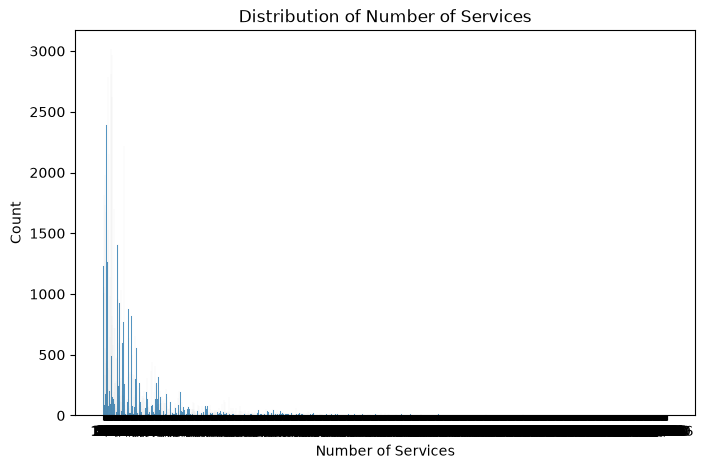

In [47]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Number of Services"], bins=50)

plt.title("Distribution of Number of Services")
plt.xlabel("Number of Services")

plt.show()

In [48]:
df["Number of Medicare Beneficiaries"].describe()

count     100000
unique      1274
top           11
freq        4791
Name: Number of Medicare Beneficiaries, dtype: object

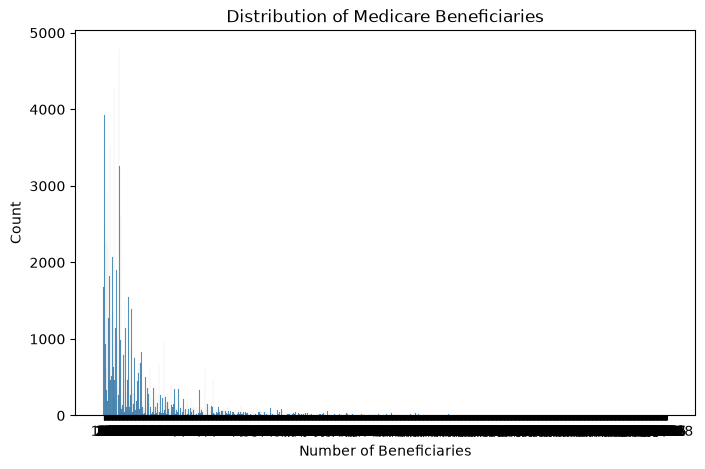

In [49]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Number of Medicare Beneficiaries"],
    bins=50
)

plt.title("Distribution of Medicare Beneficiaries")
plt.xlabel("Number of Beneficiaries")

plt.show()

In [ ]:
payment_col = "Average Medicare Payment Amount"

df[payment_col].describe()

count     100000
unique     83364
top         2.94
freq         623
Name: Average Medicare Payment Amount, dtype: object

In [4]:
df = pd.read_csv(r"C:\Users\A D M I N\Documents\Healthcare Providers-capstone1 u.csv")
df

print(df.shape)
print(df.head())

(100000, 27)
     index  National Provider Identifier  \
0  8774979                    1891106191   
1  3354385                    1346202256   
2  3001884                    1306820956   
3  7594822                    1770523540   
4   746159                    1073627758   

  Last Name/Organization Name of the Provider First Name of the Provider  \
0                                 UPADHYAYULA                  SATYASREE   
1                                       JONES                      WENDY   
2                                    DUROCHER                    RICHARD   
3                                     FULLARD                     JASPER   
4                                    PERROTTI                    ANTHONY   

  Middle Initial of the Provider Credentials of the Provider  \
0                            NaN                        M.D.   
1                              P                        M.D.   
2                              W                         DPM   
3        

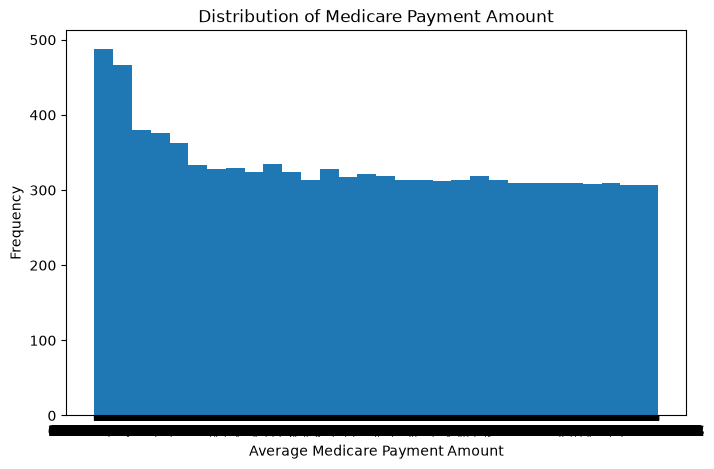

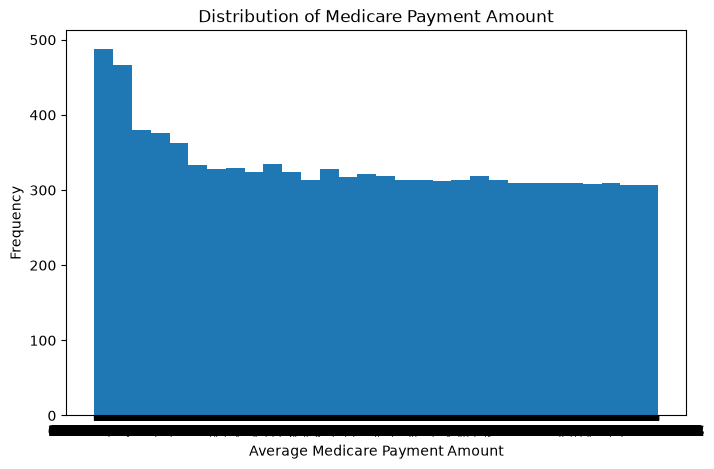

In [5]:
sample = df["Average Medicare Payment Amount"].dropna().sample(
    n=min(10000, df["Average Medicare Payment Amount"].notna().sum()),
    random_state=42
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(sample, bins=30)

ax.set_title("Distribution of Medicare Payment Amount")
ax.set_xlabel("Average Medicare Payment Amount")
ax.set_ylabel("Frequency")

fig

In [6]:
df = pd.read_csv(r"C:\Users\A D M I N\Documents\Healthcare Providers-capstone1 u.csv")
df
print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (100000, 27)


In [7]:
sample_df = df.sample(
    n=min(2000, len(df)),
    random_state=42
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    sample_df["Average Medicare Allowed Amount"],
    sample_df["Average Medicare Payment Amount"],
    s=10,
    alpha=0.5
)

ax.set_title("Medicare Allowed Amount vs Medicare Payment")
ax.set_xlabel("Average Medicare Allowed Amount")
ax.set_ylabel("Average Medicare Payment Amount")

fig.savefig(
    "medicare_allowed_vs_payment.png",
    dpi=120
)

plt.close(fig)

print("SUCCESS - chart saved as medicare_allowed_vs_payment.png")

SUCCESS - chart saved as medicare_allowed_vs_payment.png


In [9]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation

,index,National Provider Identifier,Zip Code of the Provider
index,1.000000,0.999917,0.001184
National Provider Identifier,0.999917,1.000000,0.001047
Zip Code of the Provider,0.001184,0.001047,1.000000


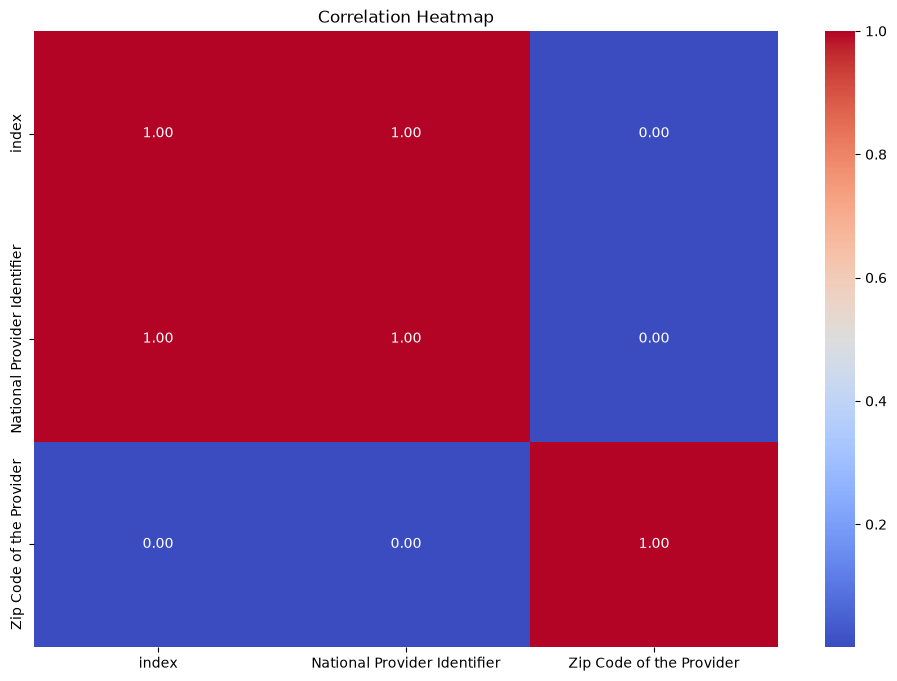

In [10]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [11]:
provider_services = (
    df.groupby("Provider Type")["Number of Services"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

provider_services

Provider Type
Mammography Center                                                                           90154130
Ambulance Service Provider                          8752097324962816262201,73,026.10965433,997.203...
Geriatric Medicine                                  8618193589125153171632321617133041553129530461...
Advanced Heart Failure and Transplant Cardiology                                                   81
Urology                                             7816250944441570,70015142451116104704943311632...
Centralized Flu                                     781592181944,965142273928493777722475615615202...
Ophthalmology                                       7723235751775,234681452463,6761622331,54142210...
Anesthesiology Assistant                            6734151819231523122412111744262062771355331517...
General Practice                                    6518731192312744811631211181111692235154831243...
Pain Management                                     6342827182344240

In [14]:
state_services = (
    df.groupby("State Code of the Provider")["Number of Services"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 States by Number of Services:")
print(state_services)

Top 10 States by Number of Services:
State Code of the Provider
WY    9625274844046165111284687286171613753534981419...
NH    8489841152520030242174403311141881423100353113...
TN    79173632036477590163492923372175343722151,4801...
IN    71131,3006342186292810221835984755332395812722...
WV    6339507271358592142,61511329282892117623838111...
MD    6112611159925029141142103711874413026371551352...
AL    6012353518126036086816611911397344735180947227...
UT    5727562269193729324610132194416345304695161115...
AK    5618604826182764117114137112121154023440125011...
IL    5521212824162115203858215268468921482051141,19...
Name: Number of Services, dtype: str


In [15]:
service_volume = (
    df.groupby("HCPCS Description")["Number of Services"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

service_volume

HCPCS Description
Evaluation of physical therapy, typically 30 minutes                                                                                  9946182810645192233047165340162315122121178024...
Serotonin (hormone) level                                                                                                                                                           993
Gonadotropin (reproductive hormone) analysis                                                                                                                                       9913
Gene analysis (breast and related cancers), genomic sequence                                                                                                                         99
Ultrasound follow-up study                                                                                                                                                9856482626107
Exercise or drug-induced heart and blood vessel stress test wi

In [18]:
import pandas as pd
import numpy as np

# Clean and convert Number of Services
df["Number of Services"] = (
    df["Number of Services"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Number of Services"] = pd.to_numeric(
    df["Number of Services"],
    errors="coerce"
)

# Clean and convert Number of Medicare Beneficiaries
df["Number of Medicare Beneficiaries"] = (
    df["Number of Medicare Beneficiaries"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Number of Medicare Beneficiaries"] = pd.to_numeric(
    df["Number of Medicare Beneficiaries"],
    errors="coerce"
)

# Create Service per Beneficiary
df["Service per Beneficiary"] = (
    df["Number of Services"] /
    df["Number of Medicare Beneficiaries"].replace(0, np.nan)
)

print("SUCCESS")
print(df["Service per Beneficiary"].head(10))

SUCCESS
0    1.125000
1    1.000000
2    2.461538
3    1.111111
4    1.375000
5    5.333333
6    1.105263
7    1.040000
8    1.073529
9    1.187500
Name: Service per Beneficiary, dtype: float64


In [19]:
print(df[[
    "Number of Services",
    "Number of Medicare Beneficiaries",
    "Service per Beneficiary"
]].dtypes)

Number of Services                  float64
Number of Medicare Beneficiaries      int64
Service per Beneficiary             float64
dtype: object


In [20]:
print(df["Number of Services"].head(10).tolist())
print(df["Number of Medicare Beneficiaries"].head(10).tolist())

print(df["Number of Services"].dtype)
print(df["Number of Medicare Beneficiaries"].dtype)

[27.0, 175.0, 32.0, 20.0, 33.0, 192.0, 21.0, 52.0, 73.0, 19.0]
[24, 175, 13, 18, 24, 36, 19, 50, 68, 16]
float64
int64
